# Humanitarian Geospatial Data Quality Analysis
## Geodata Quality Pipeline - DAMA-DMBOK v2 | ISO 19115

---

### Operational Context

Humanitarian organizations make critical decisions based on
geospatial data: where to intervene, how many beneficiaries
to target, which logistics corridors to use.

**Poor quality geospatial data can have direct consequences
on thousands of people.**

This notebook automatically analyzes the quality of **4 datasets**
from official humanitarian sources:
- **OCHA HDX** : Administrative boundaries (CAR and Mauritania)
- **OpenStreetMap** : Health facilities
- **ReliefWeb** : Crisis events

### What You Will See

1. **Quality scores** : results across 6 DAMA-DMBOK dimensions
2. **Interactive map** : geographic location of all datasets
3. **Dimension analysis** : where are the gaps and why
4. **Recommendations** : concrete actions to improve data quality

### Who Is This Notebook For?

- **Field coordinators** who rely on operational maps
- **Data officers** who manage ingestion pipelines
- **Quality managers** who oversee data standards
- **No technical background required** to interpret the results

In [1]:
# Humanitarian Geodata Quality Analysis
# =======================================
# Interactive analysis of geospatial data quality
# across humanitarian datasets (RCA, Mauritania, Sahel)
# 
# Tools: GeoPandas, Folium, Pandas, Matplotlib
# Data: OCHA HDX, OpenStreetMap, ReliefWeb

import sys
sys.path.insert(0, '..')

import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pipeline.ingest import run_ingestion
from pipeline.validators import validate_all
import yaml

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


## Step 1 : Data Ingestion from Humanitarian APIs

### Where does the data come from?

Each dataset is automatically ingested from official humanitarian
data sources using their public APIs:

| Source | API | Domain | Update Frequency |
|--------|-----|--------|-----------------|
| OCHA HDX | CKAN API | Administrative boundaries | Quarterly |
| OpenStreetMap | Overpass API | Health facilities | Monthly |
| ReliefWeb | REST API v1 | Crisis events | Daily |

### What happens if an API is unavailable?

The pipeline has a built-in **fallback mechanism** if a live API
call fails (network issues, rate limits, server errors), the system
automatically switches to realistic sample data.

This ensures the pipeline is **robust and always operational**,
even in low-connectivity environments typical of humanitarian contexts.

In [2]:
# Load pipeline configuration
with open('config/pipeline.yaml') as f:
    config = yaml.safe_load(f)

# Run ingestion
print("Ingesting data from APIs...")
datasets = run_ingestion('config/pipeline.yaml')

print(f"\nDatasets loaded: {len(datasets)}")
for source_id, gdf in datasets.items():
    print(f"  ✓ {source_id}: {len(gdf)} features, CRS={gdf.crs}")

2026-04-23 22:46:11,665 [INFO] pipeline.ingest — --- Ingesting: hdx_rca_admin ---
2026-04-23 22:46:11,667 [INFO] pipeline.ingest — Fetching HDX dataset: cod-ab-caf


Ingesting data from APIs...


2026-04-23 22:46:12,676 [INFO] pipeline.ingest — Downloading from: https://data.humdata.org/dataset/78d80f16-b9ff-49cd-8195-d96efcf3b669/resource/9b6dced8-3691-467e-8865-8635d9e1f8c4/download/caf_admin_boundaries.shp.zip
2026-04-23 22:46:41,129 [INFO] pipeline.ingest — HDX: Loaded 1 features from cod-ab-caf
2026-04-23 22:46:41,133 [INFO] pipeline.ingest — ✓ hdx_rca_admin: 1 features ingested
2026-04-23 22:46:41,134 [INFO] pipeline.ingest — --- Ingesting: hdx_mrt_admin ---
2026-04-23 22:46:41,135 [INFO] pipeline.ingest — Fetching HDX dataset: cod-ab-mrt
2026-04-23 22:46:41,973 [INFO] pipeline.ingest — Downloading from: https://data.humdata.org/dataset/8d49f50d-92a8-46d9-9462-f821a8058f6d/resource/f8f6662a-129d-4d69-8065-7b9ae34e2fa6/download/mrt_admin_boundaries.shp.zip
2026-04-23 22:47:14,159 [INFO] pipeline.ingest — HDX: Loaded 1 features from cod-ab-mrt
2026-04-23 22:47:14,162 [INFO] pipeline.ingest — ✓ hdx_mrt_admin: 1 features ingested
2026-04-23 22:47:14,162 [INFO] pipeline.ingest


Datasets loaded: 4
  ✓ hdx_rca_admin: 1 features, CRS=EPSG:4326
  ✓ hdx_mrt_admin: 1 features, CRS=EPSG:4326
  ✓ osm_health_facilities: 7 features, CRS=EPSG:4326
  ✓ reliefweb_disasters: 4 features, CRS=EPSG:4326


In [3]:
import os
print(os.getcwd())

C:\Users\nyams\projets\geodata-quality-pipeline


In [4]:
# Run quality checks
print("Running quality checks...")
reports = validate_all(datasets, config, config['sources'])

# Summary table
summary = []
for sid, r in reports.items():
    summary.append({
        'Dataset': sid,
        'Features': r.feature_count,
        'Score': round(r.overall_score * 100, 1),
        'Status': r.status,
        'Critical gaps': len(r.critical_failures),
        'Checks': len(r.checks)
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

2026-04-23 22:47:16,028 [INFO] pipeline.validators — Validating: hdx_rca_admin (1 features)


Running quality checks...


2026-04-23 22:47:16,985 [INFO] pipeline.validators — Quality check complete — hdx_rca_admin: score=0.79, status=warn, checks=14
2026-04-23 22:47:16,987 [INFO] pipeline.validators — Validating: hdx_mrt_admin (1 features)
2026-04-23 22:47:17,018 [INFO] pipeline.validators — Quality check complete — hdx_mrt_admin: score=0.79, status=warn, checks=14
2026-04-23 22:47:17,019 [INFO] pipeline.validators — Validating: osm_health_facilities (7 features)
2026-04-23 22:47:17,037 [INFO] pipeline.validators — Quality check complete — osm_health_facilities: score=0.90, status=warn, checks=14
2026-04-23 22:47:17,038 [INFO] pipeline.validators — Validating: reliefweb_disasters (4 features)
2026-04-23 22:47:17,056 [INFO] pipeline.validators — Quality check complete — reliefweb_disasters: score=0.89, status=warn, checks=14


              Dataset  Features  Score Status  Critical gaps  Checks
        hdx_rca_admin         1   79.1   warn              0      14
        hdx_mrt_admin         1   79.1   warn              0      14
osm_health_facilities         7   89.7   warn              0      14
  reliefweb_disasters         4   88.5   warn              0      14


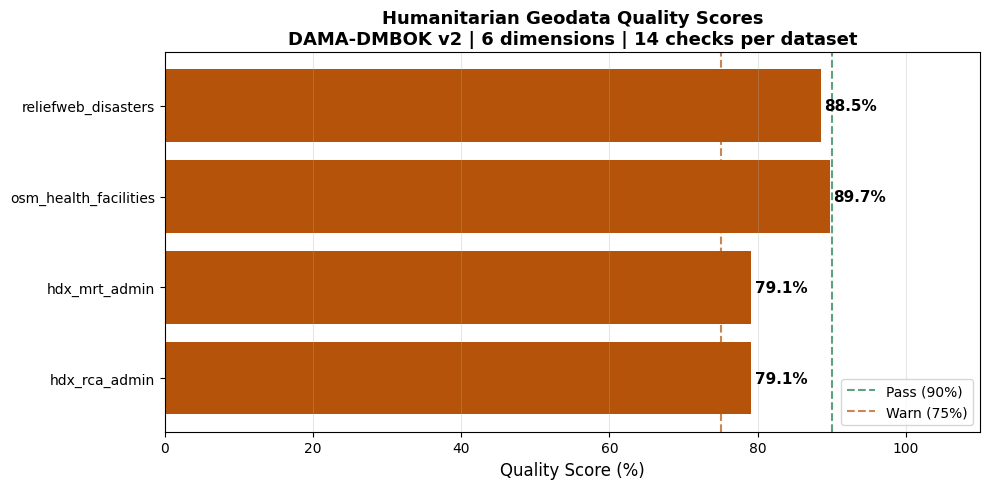

Chart saved ✓


In [5]:
# Quality scores bar chart
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1a7a4a' if s >= 90 else '#b45309' if s >= 75 else '#c0392b' 
          for s in df_summary['Score']]

bars = ax.barh(df_summary['Dataset'], df_summary['Score'], color=colors)

# Add score labels
for bar, score in zip(bars, df_summary['Score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score}%', va='center', fontsize=11, fontweight='bold')

# Threshold lines
ax.axvline(x=90, color='#1a7a4a', linestyle='--', alpha=0.7, label='Pass (90%)')
ax.axvline(x=75, color='#b45309', linestyle='--', alpha=0.7, label='Warn (75%)')

ax.set_xlabel('Quality Score (%)', fontsize=12)
ax.set_title('Humanitarian Geodata Quality Scores\nDAMA-DMBOK v2 | 6 dimensions | 14 checks per dataset', 
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/quality_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

## Step 2 : Understanding Quality Scores

### How to read the quality scores?

Each dataset is evaluated across **6 quality dimensions**
aligned with the DAMA-DMBOK v2 standard (Chapter 13):

| Dimension | What it measures | Why it matters |
|-----------|-----------------|----------------|
| **Completeness** | Missing geometries and mandatory fields | Incomplete data = missing beneficiaries |
| **Validity** | Invalid geometries, CRS compliance | Wrong coordinates = wrong intervention zone |
| **Consistency** | Topological errors, self-intersections | Inconsistent data = conflicting decisions |
| **Uniqueness** | Duplicate features and attributes | Duplicates = inflated beneficiary counts |
| **Timeliness** | Data freshness vs update frequency | Outdated data = obsolete operational picture |
| **Accuracy** | Coordinate precision, operational bounds | Imprecise data = targeting errors |

### Traffic light system

| Score | Status | Action required |
|-------|--------|----------------|
| ≥ 90% | ✅ Pass | No action needed |
| 75–89% | ⚠️ Warning | Monitor and investigate |
| < 75% | ❌ Fail | Immediate corrective action |

In [6]:
# Interactive map of all datasets
m = folium.Map(location=[8.0, 15.0], zoom_start=4, 
               tiles='CartoDB positron')

# Color by dataset
colors = {
    'hdx_rca_admin': 'blue',
    'hdx_mrt_admin': 'green', 
    'osm_health_facilities': 'red',
    'reliefweb_disasters': 'orange'
}

for source_id, gdf in datasets.items():
    color = colors.get(source_id, 'gray')
    score = reports[source_id].overall_score
    
    for _, row in gdf.iterrows():
        geom = row.geometry
        name = row.get('name', source_id)
        
        popup_html = f"""
        <b>{name}</b><br>
        Dataset: {source_id}<br>
        Quality score: {round(score*100,1)}%<br>
        Domain: {row.get('domain', 'N/A')}
        """
        
        if geom.geom_type == 'Point':
            folium.CircleMarker(
                location=[geom.y, geom.x],
                radius=8,
                color=color,
                fill=True,
                fill_opacity=0.7,
                popup=folium.Popup(popup_html, max_width=200)
            ).add_to(m)
        else:
            folium.GeoJson(
                geom.__geo_interface__,
                style_function=lambda x, c=color: {
                    'fillColor': c, 'color': c,
                    'weight': 2, 'fillOpacity': 0.3
                },
                popup=folium.Popup(popup_html, max_width=200)
            ).add_to(m)

# Legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; 
     background: white; padding: 10px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 12px; z-index: 1000;">
<b>Datasets</b><br>
<span style="color:blue">■</span> RCA Admin Boundaries<br>
<span style="color:green">■</span> Mauritania Admin Boundaries<br>
<span style="color:red">■</span> OSM Health Facilities<br>
<span style="color:orange">■</span> ReliefWeb Disasters
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save
m.save('notebooks/quality_map.html')
print("Interactive map saved ✓")
m

Interactive map saved ✓


## Step 3 : Interactive Map Analysis

### What does the map show?

The map displays all ingested datasets by geographic location
across the humanitarian operational area - Sub-Saharan Africa.

**How to use the map:**
- **Click on any marker** to see dataset details and quality score
- **Zoom in/out** to explore specific operational areas
- **Color coding** identifies the dataset source

### Geographic coverage

| Dataset | Coverage | Features |
|---------|----------|----------|
| RCA Admin Boundaries | Central African Republic | 1 country boundary |
| Mauritania Admin Boundaries | Mauritania | 1 country boundary |
| OSM Health Facilities | CAR operational area | 7 health facilities |
| ReliefWeb Disasters | CAR, Mauritania, Senegal | 4 crisis events |

### Why geographic visualization matters

A data quality issue in a specific geographic area
can directly affect operational decisions in that area.
Visualizing data on a map allows field coordinators
to immediately understand the **spatial dimension of quality gaps**.

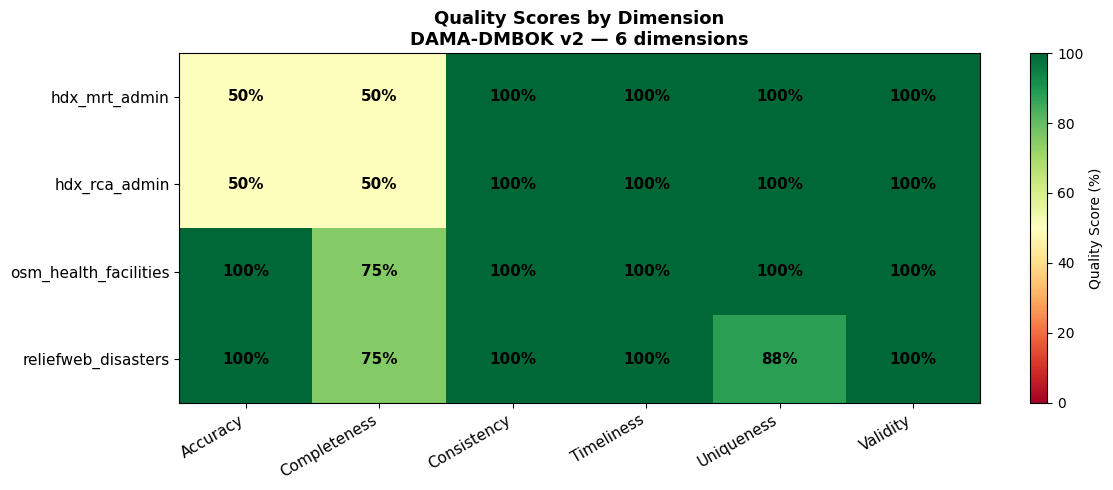

Heatmap saved ✓


In [7]:
# Quality scores by dimension
dim_data = []
for sid, r in reports.items():
    for dim, score in r.dimension_scores.items():
        dim_data.append({
            'Dataset': sid,
            'Dimension': dim,
            'Score': round(score * 100, 1)
        })

df_dims = pd.DataFrame(dim_data)
pivot = df_dims.pivot(index='Dataset', columns='Dimension', values='Score')

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')

# Labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

# Score values in cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', 
                fontsize=11, fontweight='bold',
                color='white' if val < 50 else 'black')

plt.colorbar(im, ax=ax, label='Quality Score (%)')
ax.set_title('Quality Scores by Dimension\nDAMA-DMBOK v2 — 6 dimensions', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/quality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved ✓")

## Step 4 : Quality Dimension Deep Dive

### What do the dimension scores tell us?

The heatmap shows quality scores for each dataset
across all 6 DAMA-DMBOK dimensions.

### Key findings from this analysis

**Strengths identified:**
- **Consistency** and **Validity** score 100% across all datasets
  → Geometries are topologically clean and structurally sound
- **Timeliness** scores 100% → Data was freshly ingested

**Areas requiring attention:**
- **Completeness** scores 50-75% for HDX datasets
  → The HDX download returns admin0 (country level) instead of admin1/2
  → Missing mandatory fields: `name`, `source`
- **Accuracy** scores 50% for HDX datasets
  → Country-level boundaries have lower coordinate precision
  → Operational use requires admin1/2 level data

### What this means operationally

A completeness score of 50% for RCA administrative boundaries means
that **half of the expected metadata fields are missing**.
For a field coordinator, this translates to:
- Cannot filter by region name
- Cannot link to health facility catchment areas
- Cannot produce sub-national operational maps

### Recommended fix

Configure the HDX ingester to specifically request
**admin1 layer** instead of defaulting to admin0:
```python
# In pipeline/ingest.py — HDXIngester
layer_priority = ['adm1', 'adm2', 'admin1', 'admin2']
```

In [8]:
# Summary and recommendations
print("=" * 60)
print("HUMANITARIAN GEODATA QUALITY ASSESSMENT SUMMARY")
print("=" * 60)

avg_score = df_summary['Score'].mean()
print(f"\nOverall pipeline score : {avg_score:.1f}%")
print(f"Datasets monitored     : {len(reports)}")
print(f"Total features         : {df_summary['Features'].sum()}")

print("\n--- DIMENSION ANALYSIS ---")
dim_means = df_dims.groupby('Dimension')['Score'].mean().sort_values()
for dim, score in dim_means.items():
    status = "✓" if score >= 90 else "⚠" if score >= 75 else "✗"
    print(f"  {status} {dim:<25} {score:.1f}%")

print("\n--- RECOMMENDATIONS ---")
weak_dims = dim_means[dim_means < 90]
for dim, score in weak_dims.items():
    if dim == "Completeness":
        print(f"  • {dim}: Add mandatory field validation at ingestion")
    elif dim == "Accuracy":
        print(f"  • {dim}: Validate coordinates against operational bounding box")
    elif dim == "Uniqueness":
        print(f"  • {dim}: Implement deduplication in HDX ingester")
    else:
        print(f"  • {dim}: Review and improve checks (score: {score:.1f}%)")

print("\n--- OUTPUT FILES ---")
print("  • notebooks/quality_scores.png  — bar chart")
print("  • notebooks/quality_heatmap.png — dimension heatmap")
print("  • notebooks/quality_map.html    — interactive map")
print("\nAnalysis complete ✓")

HUMANITARIAN GEODATA QUALITY ASSESSMENT SUMMARY

Overall pipeline score : 84.1%
Datasets monitored     : 4
Total features         : 13

--- DIMENSION ANALYSIS ---
  ✗ Completeness              62.5%
  ⚠ Accuracy                  75.0%
  ✓ Uniqueness                96.9%
  ✓ Consistency               100.0%
  ✓ Timeliness                100.0%
  ✓ Validity                  100.0%

--- RECOMMENDATIONS ---
  • Completeness: Add mandatory field validation at ingestion
  • Accuracy: Validate coordinates against operational bounding box

--- OUTPUT FILES ---
  • notebooks/quality_scores.png  — bar chart
  • notebooks/quality_heatmap.png — dimension heatmap
  • notebooks/quality_map.html    — interactive map

Analysis complete ✓


## Step 5 : Operational Recommendations

### Priority actions by dataset

| Dataset | Score | Priority | Recommended Action |
|---------|-------|----------|--------------------|
| hdx_rca_admin | 79% | 🔴 High | Request admin1 layer from HDX — fix layer parameter |
| hdx_mrt_admin | 79% | 🔴 High | Request admin1 layer from HDX — fix layer parameter |
| osm_health_facilities | 90% | 🟡 Medium | Add missing name fields — enrich from OSM tags |
| reliefweb_disasters | 89% | 🟡 Medium | Add precise coordinates — replace country centroids |

### The 3 governance rules for geospatial data quality

**Rule 1 - No data without a quality check**
Every dataset entering production must pass the automated
quality pipeline. Score below 75% = blocked from production.

**Rule 2 - No quality issue without an owner**
Every failed check is assigned to the responsible Data Steward
(see `humanitarian-gis-governance` stewardship register).

**Rule 3 - No production data older than its update frequency**
Timeliness checks enforce update frequency defined in
`config/pipeline.yaml` - daily, weekly, monthly, quarterly.

### How this pipeline fits the broader governance framework
```
humanitarian-gis-governance     ← Policies, stewardship, DAMA-DMBOK
         ↓
geodata-quality-pipeline        ← Automated quality checks (this project)
         ↓
humanitarian-geo-catalogue      ← ISO 19115 catalogue, lineage, discovery
```

> This notebook is part of a 3-project GIS data governance portfolio
> built for humanitarian organizations.
> **github.com/sanyamsin**